# Neural Networks Approach

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import statsmodels.api as sm

In [3]:
import matplotlib.pyplot as plt

# Covid

In [4]:
df_covid = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/gold/covid_multivariate_w_2.csv')
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [5]:
# create shifted cases (t+1)
df_covid['cases_1'] = df_covid.groupby('country')['cases'].shift(-1)


In [6]:
# numerical stamp for the datetime
df_covid["date"] = pd.to_datetime(df_covid["date"])
df_covid["date_numeric"] = df_covid["date"].view("int64") // 10**9  # seconds since epoch

# drop rows where the shifted target is NaN (last day in each country)
df_covid = df_covid.dropna(subset=["cases_1"]).reset_index(drop=True)

<ipython-input-6-6218ae88c54a>:3: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_covid["date_numeric"] = df_covid["date"].view("int64") // 10**9  # seconds since epoch


In [7]:
df_original_covid = df_covid.copy()

# Experiment

In [ ]:
df_col = df_covid[df_covid['country'] == 'Colombia']
df_col

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,cases_1,date_numeric
144,2020-03-23,Colombia,471,3465,6.007143,7.164286,18.142857,48.857143,118.285714,0.742857,50326931,28,10,6,44,7.531667,78.171429,0.000000,8088.0,1584921600
145,2020-03-30,Colombia,783,8088,5.992857,6.228571,13.057143,25.214286,63.214286,0.628571,50326931,31,8,6,40,4.344286,87.960000,0.000000,15594.0,1585526400
146,2020-04-06,Colombia,1291,15594,4.335714,4.700000,11.757143,15.214286,37.285714,0.614286,50326931,40,8,6,38,2.705714,87.960000,0.000000,23021.0,1586131200
147,2020-04-13,Colombia,1016,23021,5.028571,7.000000,12.092857,31.571429,74.785714,0.642857,50326931,27,8,5,31,1.977143,84.788571,0.000000,32445.0,1586736000
148,2020-04-20,Colombia,1587,32445,5.207143,7.192857,9.607143,23.071429,53.500000,0.442857,50326931,24,7,5,29,2.207143,85.451429,0.000000,46219.0,1587340800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2022-11-21,Colombia,0,44188599,12.914286,12.471429,3.957143,32.571429,61.928571,0.542857,51443283,22,7,4,24,15.328571,19.440000,70.988571,44192949.0,1668988800
284,2022-11-28,Colombia,1450,44192949,10.078571,11.414286,4.650000,30.500000,58.642857,0.685714,51443283,12,6,5,24,15.254286,19.440000,71.040000,44213264.0,1669593600
285,2022-12-05,Colombia,2903,44213264,6.214286,11.164286,4.492857,32.642857,63.428571,0.514286,51443283,13,11,5,27,15.428571,19.440000,71.040000,44240154.0,1670198400
286,2022-12-12,Colombia,5271,44240154,6.285714,10.728571,4.085714,35.642857,60.857143,0.500000,51443283,12,11,4,25,15.705714,19.440000,71.061429,44276091.0,1670803200


In [ ]:
# prompt: create a linear regression model using statsmodels.api, that takes as target 'cases_1' and as predictors all columns in df_col except the target and the columns 'country', 'date'

# Define target and predictors
target = 'cases_1'
predictors = [col for col in df_col.columns if col not in ['cases_1', 'country', 'date']]

# Create the linear regression model
X = df_col[predictors]
y = df_col[target]
X = sm.add_constant(X) # adding a constant
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                cases_1   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.626e+05
Date:                Mon, 05 May 2025   Prob (F-statistic):          2.56e-313
Time:                        13:43:22   Log-Likelihood:                -1749.1
No. Observations:                 144   AIC:                             3534.
Df Residuals:                     126   BIC:                             3588.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [ ]:
# prompt: create a linear regression model using sklearn, that takes as target 'cases_1' and as predictors all columns in df_col except the target and the columns 'country', 'date'. But first do a train test split using the 80% of the oldest data as train and 20% of the newest as test. Use the column 'date' to sort the dataframe

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Define target and predictors
target = 'cases_1'
predictors = [col for col in df_col.columns if col not in ['cases_1', 'country', 'date']]


# Sort the DataFrame by date
df_col = df_col.sort_values('date')

# Define the split point (80% of the oldest data)
split_point = int(0.8 * len(df_col))

# Split the data into training and testing sets
X = df_col[predictors]
y = df_col[target]
X_train = X[:split_point]
X_test = X[split_point:]
y_train = y[:split_point]
y_test = y[split_point:]

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = model.predict(X_test)

# Evaluate the model (example: R-squared)
r2 = r2_score(y_test, y_pred_linear)
print(f"R-squared: {r2}")

# get rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
print(f"RMSE: {rmse}")

R-squared: 0.8336169514910372
RMSE: 159564.91614842584


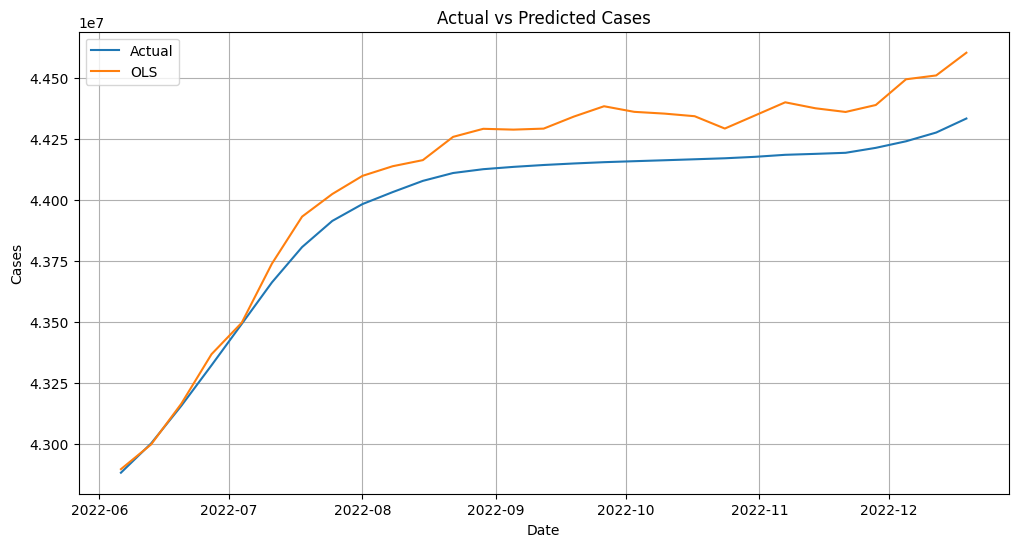

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Create a DataFrame for plotting
plot_df = pd.DataFrame({'date': df_col['date'][split_point:], 'actual': y_test, 'predicted_linear': y_pred_linear})

# Plot the actual and predicted values as time series
plt.figure(figsize=(12, 6))
plt.plot(plot_df['date'], plot_df['actual'], label='Actual')
plt.plot(plot_df['date'], plot_df['predicted_linear'], label='OLS')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.title('Actual vs Predicted Cases')
plt.legend()
plt.grid(True)
plt.show()


## RF

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

# --------------------------------------------------
# 0.  Target & predictors
# --------------------------------------------------
target = "cases_1"
predictors = [c for c in df_col.columns if c not in ["cases_1", "country", "date"]]

# chronological 80 % / 20 % split
df_col = df_col.sort_values("date")

split_point = int(0.80 * len(df_col))
X_train = df_col.iloc[:split_point][predictors]
X_test  = df_col.iloc[split_point:][predictors]

y_train = df_col.iloc[:split_point][target]
y_test  = df_col.iloc[split_point:][target]

# --------------------------------------------------
# 1.  Random‑Forest model
# --------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,        # let trees grow until pure / min_samples_leaf
    min_samples_leaf=2,    # small leaf size helps generalisation
    max_features="sqrt",   # typical default for RF
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

rf.fit(X_train, y_train)

# --------------------------------------------------
# 2.  Predict & evaluate
# --------------------------------------------------
y_pred_rf = rf.predict(X_test)
r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest  R²: {r2: .3f}")
# get rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE: {rmse}")

Random Forest  R²: -20.241
RMSE: 1802901.503295348


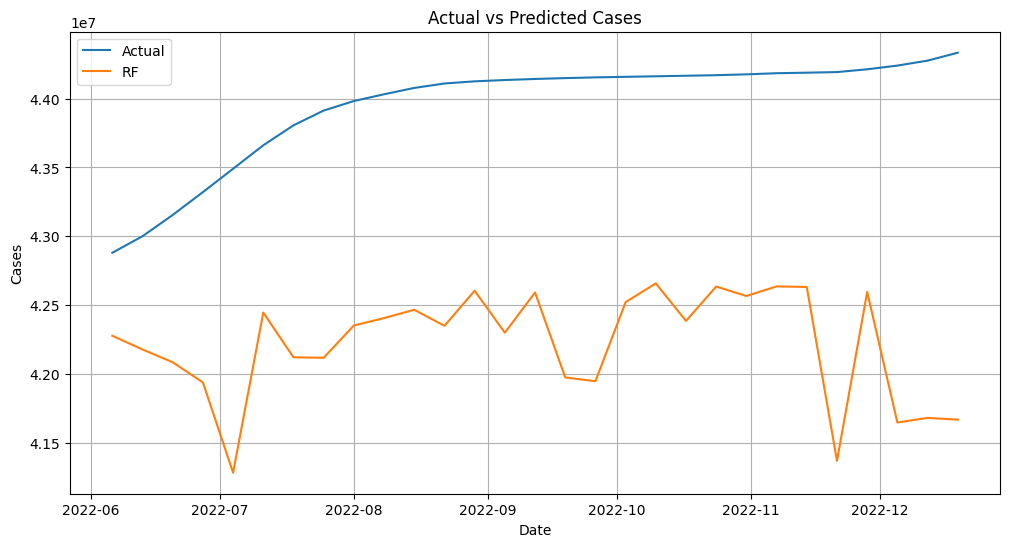

In [ ]:
# Create a DataFrame for plotting
plot_df = pd.DataFrame({'date': df_col['date'][split_point:], 'actual': y_test, 'predicted_rf': y_pred_rf})

# Plot the actual and predicted values as time series
plt.figure(figsize=(12, 6))
plt.plot(plot_df['date'], plot_df['actual'], label='Actual')
plt.plot(plot_df['date'], plot_df['predicted_rf'], label='RF')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.title('Actual vs Predicted Cases')
plt.legend()
plt.grid(True)
plt.show()


## Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
import pandas as pd

# --------------------------------------------------
# 0.  Target & predictors
# --------------------------------------------------
target = "cases_1"
predictors = [c for c in df_col.columns if c not in ["cases_1", "country", "date"]]

# chronological 80 % / 20 % split
df_col = df_col.sort_values("date")

split_point = int(0.80 * len(df_col))
X_train = df_col.iloc[:split_point][predictors]
X_test  = df_col.iloc[split_point:][predictors]

y_train = df_col.iloc[:split_point][target]
y_test  = df_col.iloc[split_point:][target]

# --------------------------------------------------
# 1.  Gradient‑Boosting model
# --------------------------------------------------
gbr = GradientBoostingRegressor(
    n_estimators=300,           # more trees → higher capacity
    learning_rate=0.05,        # shrinkage
    max_depth=3,               # tree depth (default 3)
    subsample=0.9,             # stochastic boosting for a bit of regularisation
    random_state=42
)

gbr.fit(X_train, y_train)

# --------------------------------------------------
# 2.  Predict & evaluate
# --------------------------------------------------
y_pred_gb = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting  R²: {r2: .3f}")
# get rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print(f"RMSE: {rmse}")


Gradient Boosting  R²: -12.309
RMSE: 1427087.7792918847


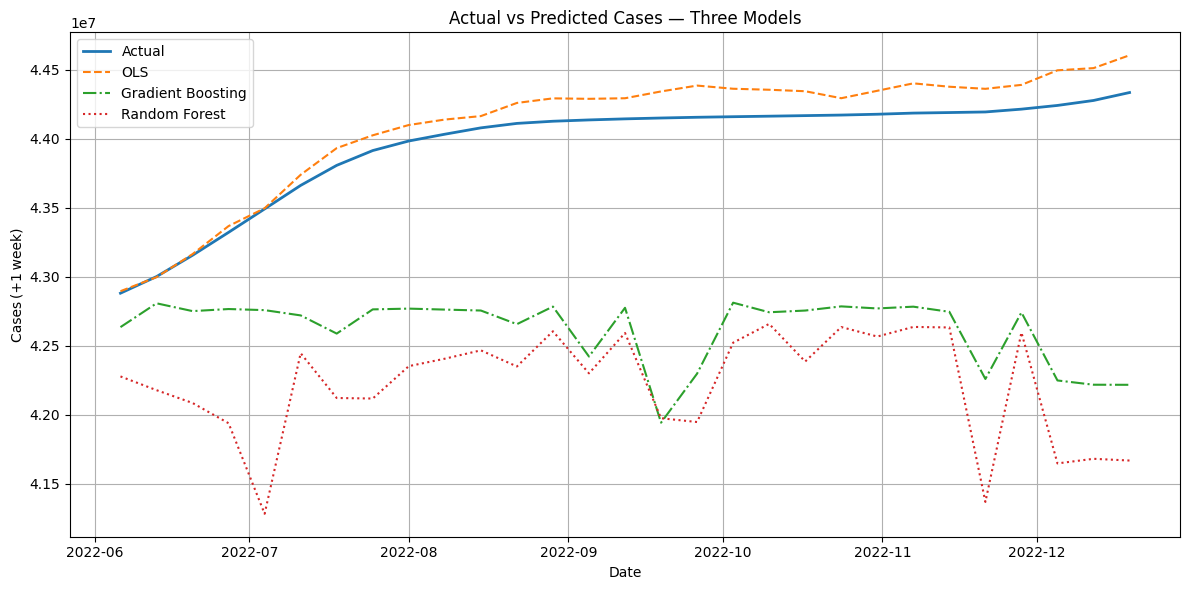

In [ ]:
# ---------------------------------------------
# 1.  Assemble everything in one tidy DataFrame
# ---------------------------------------------
plot_df = pd.DataFrame(
    {
        "date"          : df_col["date"].iloc[split_point:],   # X_test index
        "actual"        : y_test,                              # true values
        "pred_linear"   : y_pred_linear,                       # OLS
        "pred_gb"       : y_pred_gb,                           # Gradient Boosting
        "pred_rf"       : y_pred_rf                            # Random Forest
    }
)

# ---------------------------------------------
# 2.  Plot
# ---------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(plot_df["date"], plot_df["actual"],       label="Actual",            linewidth=2)
plt.plot(plot_df["date"], plot_df["pred_linear"],  label="OLS",              linestyle="--")
plt.plot(plot_df["date"], plot_df["pred_gb"],      label="Gradient Boosting", linestyle="-.")
plt.plot(plot_df["date"], plot_df["pred_rf"],      label="Random Forest",     linestyle=":")
plt.xlabel("Date")
plt.ylabel("Cases (+1 week)")
plt.title("Actual vs Predicted Cases — Three Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### NN Experiment

In [ ]:
df_nn = df_col.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# --------------------------------------------------
# 0.  Target & predictors
# --------------------------------------------------
target = "cases_1"
predictors = [c for c in df_nn.columns if c not in ["cases_1", "country"]]

# chronological split (80 % oldest rows → train/val, 20 % newest → test)
df_nn = df_nn.sort_values("date").reset_index(drop=True)
df_nn["date"] = pd.to_datetime(df_nn["date"]).view("int64") // 10**9     # numeric date

split_point = int(0.80 * len(df_nn))           # SAME test block as before
idx_trainval = np.arange(split_point)          # indices 0 … split_point‑1
idx_test      = np.arange(split_point, len(df_nn))

# ------------------------------------------------------------------
# 1.  RANDOM 80 / 20 SPLIT **INSIDE** THE TRAINING BLOCK
# ------------------------------------------------------------------
train_idx, val_idx = train_test_split(
    idx_trainval, test_size=0.20, shuffle=True, random_state=42
)
train_idx.sort()          # keep temporal order *inside* each subset (optional)
val_idx.sort()

# helper to pull arrays quickly
def take(idx, cols):
    return df_nn.loc[idx, cols].astype("float32").values

X_tr   = take(train_idx, predictors)
y_tr   = df_nn.loc[train_idx, target].astype("float32").values.reshape(-1, 1)

X_val  = take(val_idx,  predictors)
y_val  = df_nn.loc[val_idx,  target].astype("float32").values.reshape(-1, 1)

X_test = take(idx_test,  predictors)
y_test = df_nn.loc[idx_test, target].astype("float32").values.reshape(-1, 1)

# ------------------------------------------------------------------
# 2.  STANDARD SCALING (fit ONLY on *training* subset!)
# ------------------------------------------------------------------
X_scaler = StandardScaler().fit(X_tr)
X_tr_sc   = X_scaler.transform(X_tr)
X_val_sc  = X_scaler.transform(X_val)
X_test_sc = X_scaler.transform(X_test)

y_scaler = StandardScaler().fit(y_tr)
y_tr_sc   = y_scaler.transform(y_tr)
y_val_sc  = y_scaler.transform(y_val)
y_test_sc = y_scaler.transform(y_test)

# ------------------------------------------------------------------
# 3.  Build feed‑forward net
# ------------------------------------------------------------------
def build_ffn(input_dim: int):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model

model = build_ffn(len(predictors))
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_tr_sc, y_tr_sc,
    epochs=1000,
    batch_size=8,
    validation_data=(X_val_sc, y_val_sc),   # << explicit val set
    shuffle=False,                          # keep temporal order if desired
    callbacks=[es],
    verbose=0
)

# ------------------------------------------------------------------
# 4.  Predict & inverse‑transform
# ------------------------------------------------------------------
y_pred_sc = model.predict(X_test_sc, verbose=0)
y_pred_nn    = y_scaler.inverse_transform(y_pred_sc).flatten()

rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_nn))
r2   = r2_score(y_test.flatten(), y_pred_nn)

print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2: .3f}")

<ipython-input-32-7607cdecefa4>:12: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_nn["date"] = pd.to_datetime(df_nn["date"]).view("int64") // 10**9     # numeric date
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSE : 2,129,258.11
R²   : -28.627


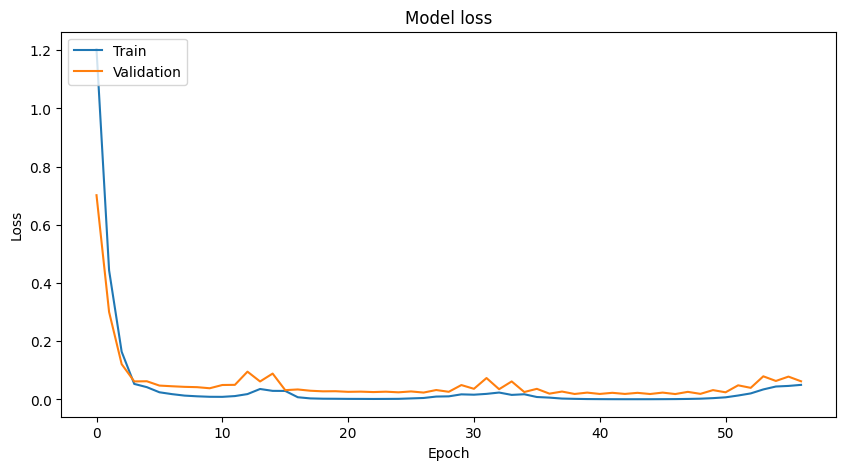

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


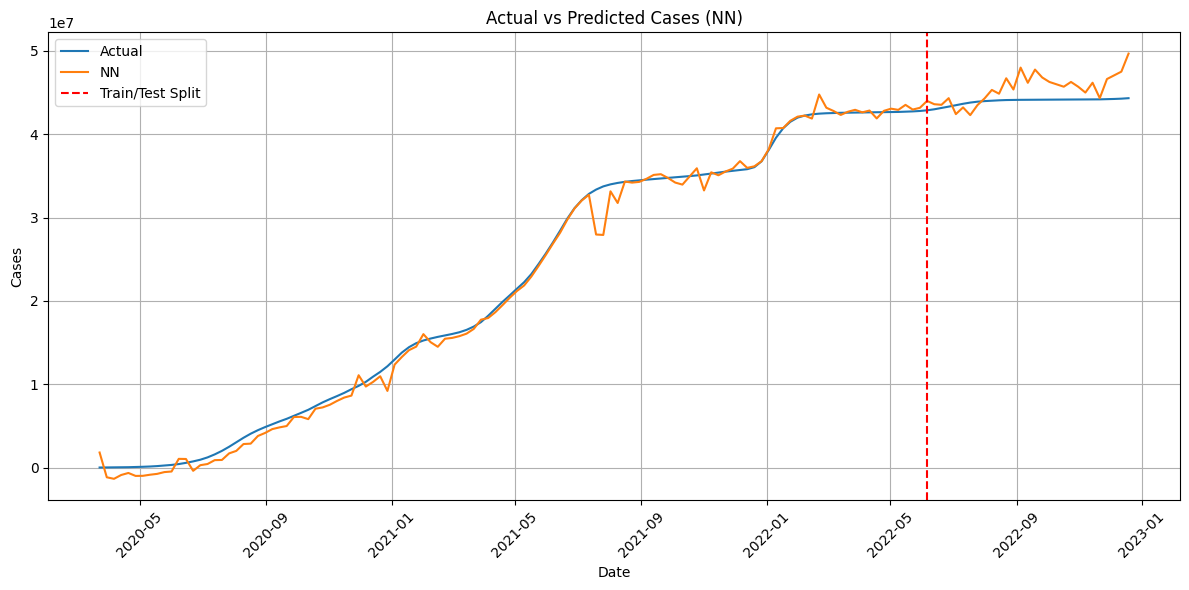

In [ ]:
# Predict on the entire dataset
X_all = df_nn[predictors].astype("float32").values
X_all_sc = X_scaler.transform(X_all)
y_pred_sc_all = model.predict(X_all_sc, verbose=0)
y_pred_nn_all = y_scaler.inverse_transform(y_pred_sc_all).flatten()

# DataFrame for plotting
plot_df_all = pd.DataFrame({
    'date': pd.to_datetime(df_original_covid[df_original_covid['country'] == 'Colombia']['date']),
    'actual': df_original_covid[df_original_covid['country'] == 'Colombia']['cases_1'],
    'predicted_nn': y_pred_nn_all
})

# Define split points
train_test_split_date = df_col['date'].iloc[split_point]


# Plot the actual and predicted values
plt.figure(figsize=(12, 6))
plt.plot(plot_df_all['date'], plot_df_all['actual'], label='Actual', linewidth=1.5)
plt.plot(plot_df_all['date'], plot_df_all['predicted_nn'], label='NN', linewidth=1.5)

# Mark train/test split
plt.axvline(x=train_test_split_date, color='red', linestyle='--', label='Train/Test Split')


# Enhancements
plt.xlabel('Date')
plt.ylabel('Cases')
plt.title('Actual vs Predicted Cases (NN)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


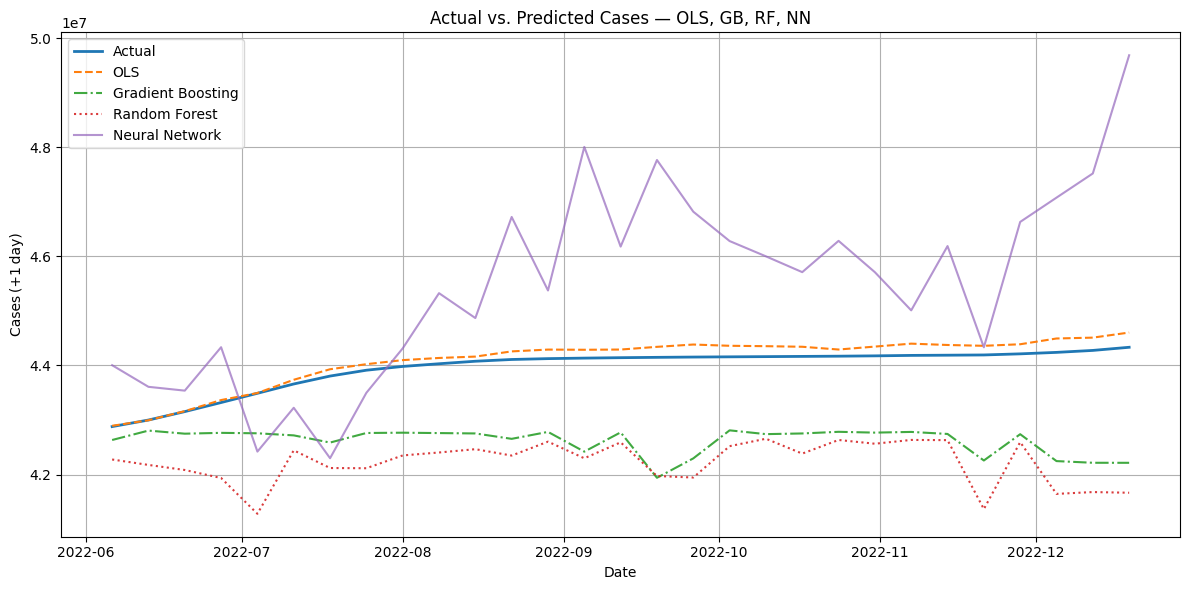

In [ ]:
# --------------------------------------------------
# 1.  Collect predictions into one DataFrame
# --------------------------------------------------
plot_df = pd.DataFrame(
    {
        "date"        : df_col["date"].iloc[split_point:],  # index of X_test
        "actual"      : y_test.flatten(),  # Flatten y_test to 1D
        "pred_linear" : y_pred_linear,   # OLS
        "pred_gb"     : y_pred_gb,       # Gradient Boosting
        "pred_rf"     : y_pred_rf,       # Random Forest
        "pred_nn"     : y_pred_nn        # Neural Network
    }
)

# --------------------------------------------------
# 2.  Plot
# --------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(plot_df["date"], plot_df["actual"],      label="Actual",            linewidth=2)
plt.plot(plot_df["date"], plot_df["pred_linear"], label="OLS",              linestyle="--")
plt.plot(plot_df["date"], plot_df["pred_gb"],     label="Gradient Boosting", linestyle="-.", alpha=0.9)
plt.plot(plot_df["date"], plot_df["pred_rf"],     label="Random Forest",     linestyle=":",  alpha=0.9)
plt.plot(plot_df["date"], plot_df["pred_nn"],     label="Neural Network",    linestyle="-",  alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Cases (+1 day)")
plt.title("Actual vs. Predicted Cases — OLS, GB, RF, NN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
df = df_covid.copy()

In [ ]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated', 'cases_1', 'date_numeric'],
      dtype='object')

In [ ]:
df = df[['country', 'new_cases', 'cases',
       'pm25',  'google_hospital','google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated', 'cases_1', 'date_numeric', 'date']]

In [ ]:
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

# ---------- user knobs ----------
TOP_K_PER_COUNTRY = 10      # how many features to keep per country
TOP_K_OVERALL     = 10
N_REPEATS         = 10     # permutation repeats
RANDOM_STATE      = 42
# ---------------------------------

feature_cols = df.columns.difference(
    ["cases_1", "country", "date"]   # target & non‑predictors
)

# keep track of votes and mean importance
vote_counter      = Counter()
imp_accumulator   = defaultdict(list)   # feature → list of importances

for country, df_c in df.groupby("country", sort=True):
    df_c = df_c.sort_values("date")           # chronological
    X_c  = df_c[feature_cols].values
    y_c  = df_c["cases_1"].values

    # quick GBM model
    gbr = GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=3, subsample=0.9,
        random_state=RANDOM_STATE
    ).fit(X_c, y_c)

    result = permutation_importance(
        gbr, X_c, y_c,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error"
    )

    country_imp = pd.Series(
        result.importances_mean, index=feature_cols
    ).sort_values(ascending=False)

    top_features = country_imp.head(TOP_K_PER_COUNTRY)

    # vote + accumulate
    vote_counter.update(top_features.index)
    for feat, imp in top_features.items():
        imp_accumulator[feat].append(imp)

# ---------------------------------
# assemble overall ranking
# ---------------------------------
overall = (
    pd.DataFrame({
        "votes" : pd.Series(vote_counter),
        "mean_imp" : {f: np.mean(v) for f, v in imp_accumulator.items()}
    })
    .sort_values(["votes", "mean_imp"], ascending=False)
)

top5_overall = overall.head(TOP_K_OVERALL)
print("Top‑5 predictors overall:\n", top5_overall)


Top‑5 predictors overall:
                                 votes      mean_imp
pop_vaccinated                      5  3.345393e+07
cases                               5  2.913813e+07
date_numeric                        5  2.542913e+07
StringencyIndex_Average             5  5.609106e+06
Mean_distance_avg_14day_movavg      5  9.949598e+05
new_cases                           5  8.179173e+05
pm25                                5  6.107552e+05
google_symptom                      5  4.158859e+05
google_hospital                     5  4.385644e+04


In [ ]:
top5_overall.index

Index(['pop_vaccinated', 'cases', 'date_numeric', 'StringencyIndex_Average',
       'Mean_distance_avg_14day_movavg', 'new_cases', 'pm25', 'google_symptom',
       'google_hospital'],
      dtype='object')

## NN

In [ ]:
df = df_covid.copy()

In [ ]:
from tensorflow.keras import backend as K          # to clear memory
# ------------------------------------------------------------------
# 0.  Network builder
# ------------------------------------------------------------------
def build_ffn(input_dim: int):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ------------------------------------------------------------------
# 1.  Loop over countries
# ------------------------------------------------------------------
target       = "cases_1"
countries    = df_covid["country"].unique()

metrics      = {}                   # {country: {"rmse":…, "r2":…}}
pred_series  = {}                   # {country: pd.Series(pred, index=date)}

for ctry in countries:
    df_nn = df_covid[df_covid["country"] == ctry].copy()
    if df_nn.empty:
        continue

    # ----- keep original date for indexing; also numeric for model -----
    df_nn = df_nn.sort_values("date").reset_index(drop=True)
    df_nn["date_dt"] = pd.to_datetime(df_nn["date"])            # human‑readable
    df_nn["date"]    = df_nn["date_dt"].view("int64") // 10**9  # numeric

    predictors = [col for col in df_nn.columns
                  if col not in [target, "country", "date_dt"]]

    # ----- temporal split -----
    split_point  = int(0.80 * len(df_nn))
    idx_trainval = np.arange(split_point)
    idx_test     = np.arange(split_point, len(df_nn))

    train_idx, val_idx = train_test_split(
        idx_trainval, test_size=0.20, shuffle=True, random_state=42
    )
    train_idx.sort(); val_idx.sort()

    take = lambda idx, cols: df_nn.loc[idx, cols].astype("float32").values

    X_tr   = take(train_idx, predictors)
    X_val  = take(val_idx,  predictors)
    X_test = take(idx_test,  predictors)

    y_tr   = df_nn.loc[train_idx, target].values.astype("float32").reshape(-1, 1)
    y_val  = df_nn.loc[val_idx,  target].values.astype("float32").reshape(-1, 1)
    y_test = df_nn.loc[idx_test, target].values.astype("float32").reshape(-1, 1)

    # ----- scaling -----
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc = map(y_scaler.transform, (y_tr, y_val))

    # ----- model -----
    model = build_ffn(len(predictors))
    es    = EarlyStopping(monitor="val_loss",
                          patience=10, restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000,
        batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False,
        callbacks=[es],
        verbose=0
    )

    # ----- evaluate on *test* -----
    y_pred_test_sc = model.predict(X_test_sc, verbose=0)
    y_pred_test    = y_scaler.inverse_transform(y_pred_test_sc).flatten()

    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[ctry] = {"rmse": rmse, "r2": r2}

    # ----- predict FULL series (train+test) -----
    X_full_sc = X_scaler.transform(df_nn[predictors].astype("float32").values)
    y_pred_full_sc = model.predict(X_full_sc, verbose=0)
    y_pred_full    = y_scaler.inverse_transform(y_pred_full_sc).flatten()

    pred_series[ctry] = pd.Series(y_pred_full,
                                  index=df_nn["date_dt"],
                                  name=ctry)

    K.clear_session()   # free GPU/CPU graph memory

<ipython-input-42-30b179a47344>:33: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_nn["date"]    = df_nn["date_dt"].view("int64") // 10**9  # numeric
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
<ipython-input-42-30b179a47344>:33: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_nn["date"]    = df_nn["date_dt"].view("int64") // 10**9  # numeric
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, p

In [ ]:
# ------------------------------------------------------------------
# 2.  Collect predictions into one DataFrame
# ------------------------------------------------------------------
pred_df = pd.concat(pred_series.values(), axis=1)
# columns already named by the series; index = dates
print(pred_df.head())
print("\nMetrics:\n", pd.DataFrame(metrics).T)


                   Chile      Colombia         Italy        Mexico          US
date_dt                                                                       
2020-03-23  2.118378e+05 -6.944743e+06  9.009382e+06  2.403430e+06 -16759632.0
2020-03-30 -3.662752e+05 -6.503718e+04  2.933637e+05  8.242297e+04  11071232.0
2020-04-06 -2.143492e+05  1.724768e+05  6.326117e+05 -2.794690e+05  11873232.0
2020-04-13 -2.872752e+05  1.521891e+06 -1.401912e+06 -2.896850e+05   6461248.0
2020-04-20  1.032599e+06 -6.784392e+05 -2.172620e+06 -5.966371e+05   4761680.0

Metrics:
                   rmse          r2
Chile     5.680913e+06   -4.717621
Colombia  5.452861e+06 -193.304611
Italy     4.157433e+07   -7.571095
Mexico    5.428987e+06   -2.721069
US        1.091706e+08  -12.944150


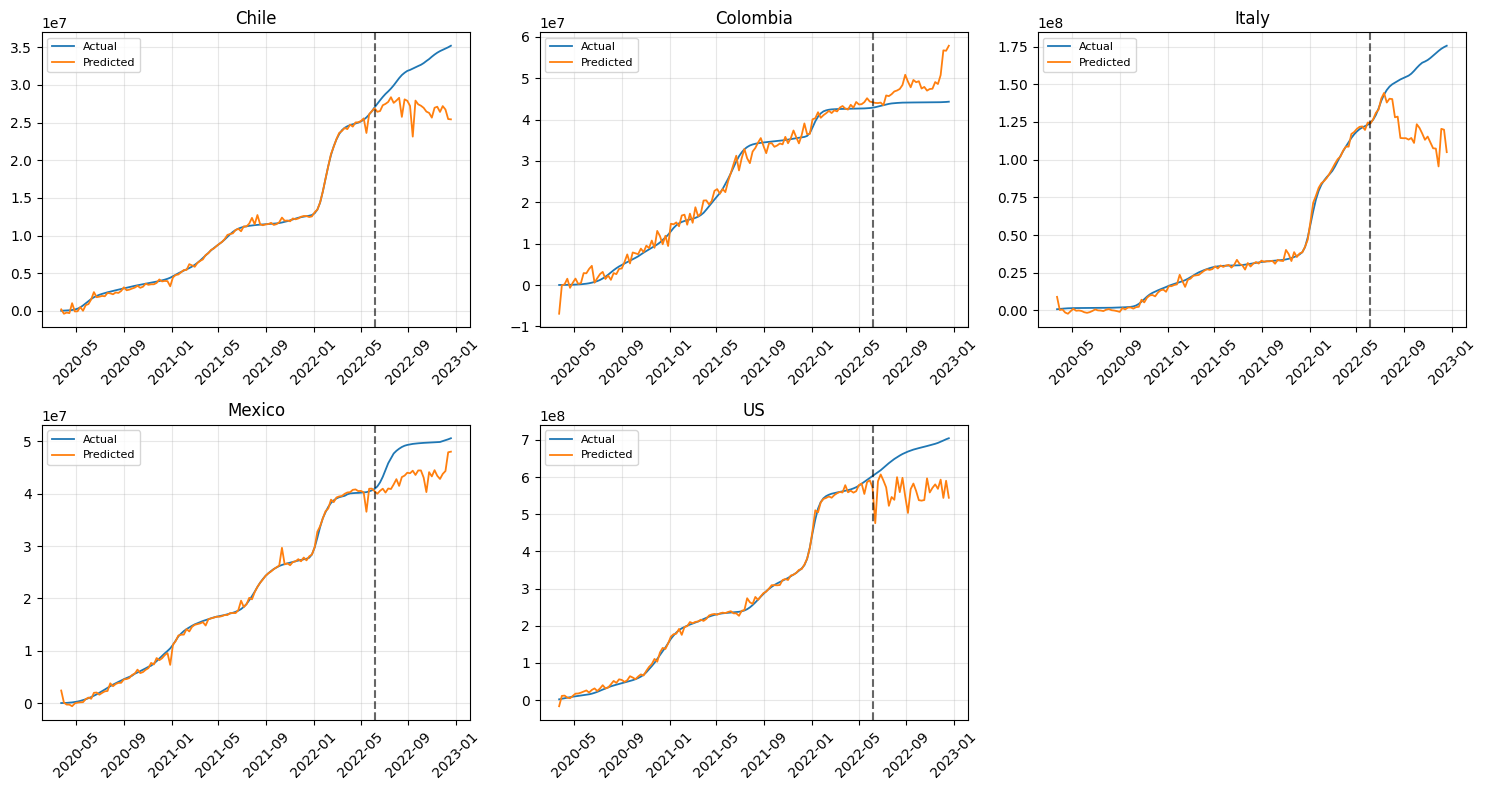

In [ ]:
import math
# ------------------------------------------------------------------
# 3.  Plot actual vs. predicted for every country
# ------------------------------------------------------------------
n_countries = len(countries)
n_cols      = math.ceil(n_countries / 2)
fig, axes   = plt.subplots(2, n_cols,
                           figsize=(5 * n_cols, 8),
                           sharex=False, sharey=False)
axes = axes.flatten()

for i, ctry in enumerate(countries):
    ax = axes[i]

    # data for this country
    df_country = (df_covid[df_covid["country"] == ctry]
                  .sort_values("date"))
    dates      = pd.to_datetime(df_country["date"])
    actual     = df_country[target].values
    preds      = pred_df[ctry].loc[dates].values

    # plot series
    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    # vertical line at train‑test split
    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.set_title(ctry)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # -------- rotate x‑ticks 45 degrees ----------
    ax.tick_params(axis="x", labelrotation=45)

# hide any unused sub‑axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

In [ ]:
from google.colab import files
# save and download pred_df as csv
pred_df.to_csv('DNN_covid.csv')
files.download('DNN_covid.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Best features selection


=== Chile ===


<ipython-input-8-45e307784830>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9


⚠️  selector empty → using cases


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Colombia ===


...


=== US ===


<ipython-input-8-45e307784830>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9


⚠️  selector empty → using cases


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Test metrics
-------------
                  rmse         r2
Chile     6.186121e+05   0.932202
Colombia  3.341802e+06 -71.978645
Italy     5.354150e+06   0.857843
Mexico    7.782485e+05   0.923534
US        2.260001e+07   0.402418


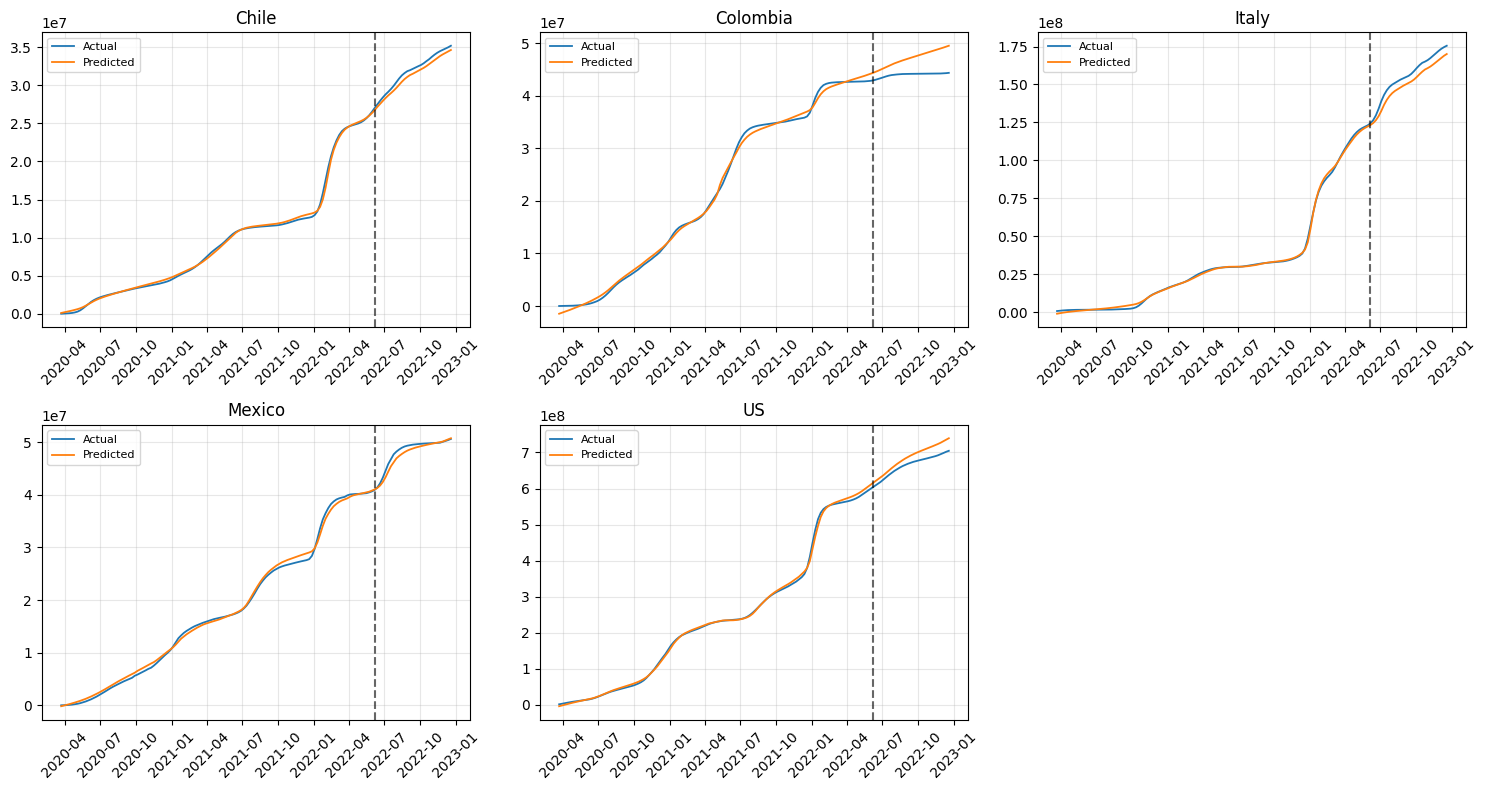

In [8]:
import matplotlib.dates as mdates
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection   import cross_val_score, KFold, train_test_split
from sklearn.metrics           import mean_squared_error, make_scorer, r2_score
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.ensemble          import GradientBoostingRegressor

from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras          import backend as K

# --------------------------------------------------
# 0.  Configuration
# --------------------------------------------------
date_col    = "date"
country_col = "country"
target_col  = "cases_1"          # shifted COVID target
countries   = df_covid[country_col].unique()   # 5 countries
cv          = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

def build_ffn(d):
    m = Sequential([
        Dense(128, activation="relu", input_shape=(d,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

# containers
best_feats = {}     # {country: [opt feature names]}
metrics    = {}     # {country: {"rmse", "r2"}}
pred_dict  = {}     # {country: pd.DataFrame([date, pred])}

# --------------------------------------------------
# 1.  Loop over countries (feature selection + NN)
# --------------------------------------------------
for ctry in countries:
    print(f"\n=== {ctry} ===")
    df = df_covid[df_covid[country_col] == ctry].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values(date_col, inplace=True)
    df["date_num"] = df[date_col].view("int64") // 10**9

    # candidate predictors = all except date, country, target
    exclude = {date_col, country_col, target_col}
    candidates = [c for c in df.columns if c not in exclude]

    # drop rows with NaN in target or any candidate
    df_fs = df.dropna(subset=[target_col] + candidates)
    if len(df_fs) < 10:
        best_feats[ctry] = []          # fallback → time only
        print("not enough data; using time only")
    else:
        # ---------- MI ranking ----------
        X_all = df_fs[candidates].values
        y_all = df_fs[target_col].values

        mi = mutual_info_regression(X_all, y_all, random_state=42)
        ranked = [candidates[i] for i in np.argsort(mi)[::-1]]

        pipe = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
            ("gbr",    GradientBoostingRegressor(random_state=42))
        ])

        best_score, best_subset = -np.inf, []
        for k in range(1, len(ranked) + 1):
            subset = ranked[:k]
            score  = cross_val_score(pipe,
                                     df_fs[subset].values, y_all,
                                     cv=cv, scoring=rmse_scorer,
                                     n_jobs=-1).mean()
            if score > best_score:
                best_score, best_subset = score, subset

        # ---- fall‑backs ----
        if not best_subset:
            if ranked:                       # fallback A: top‑1 feature
                best_subset = [ranked[0]]
                print(f"⚠️  selector empty → using {best_subset[0]}")
            else:                            # fallback B: time only
                best_subset = []
                print("⚠️  no candidates → using time only")
        else:
            print(f"{len(best_subset)} feature(s), CV‑RMSE = {-best_score:.2f}")

        best_feats[ctry] = best_subset

    # ---------------- NN training -----------------
    predictors = best_feats[ctry] + ["date_num"]
    df_clean = df.dropna(subset=[target_col] + predictors).reset_index(drop=True)
    if len(df_clean) < 10:
        print("skipped (too few rows after cleaning)")
        continue

    split_pt     = int(0.80 * len(df_clean))
    idx_trainval = np.arange(split_pt)
    idx_test     = np.arange(split_pt, len(df_clean))

    tr_idx, val_idx = train_test_split(idx_trainval, test_size=0.20,
                                       shuffle=True, random_state=42)
    tr_idx.sort(); val_idx.sort()

    X_tr   = df_clean.loc[tr_idx,  predictors].astype("float32").values
    X_val  = df_clean.loc[val_idx, predictors].astype("float32").values
    X_test = df_clean.loc[idx_test, predictors].astype("float32").values

    y_tr   = df_clean.loc[tr_idx,  target_col].astype("float32").values.reshape(-1, 1)
    y_val  = df_clean.loc[val_idx, target_col].astype("float32").values.reshape(-1, 1)
    y_test = df_clean.loc[idx_test, target_col].astype("float32").values.reshape(-1, 1)

    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc = map(y_scaler.transform, (y_tr, y_val))

    model = build_ffn(len(predictors))
    es = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000, batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False, callbacks=[es], verbose=0
    )

    y_pred_test = y_scaler.inverse_transform(
        model.predict(X_test_sc, verbose=0)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[ctry] = {"rmse": rmse, "r2": r2}

    X_full_sc = X_scaler.transform(df_clean[predictors].astype("float32").values)
    y_pred_full = y_scaler.inverse_transform(
        model.predict(X_full_sc, verbose=0)).flatten()

    pred_dict[ctry] = pd.DataFrame({date_col: df_clean[date_col],
                                    "pred": y_pred_full})
    K.clear_session()

# --------------------------------------------------
# 2.  Concatenate predictions
# --------------------------------------------------
pred_df = (pd.concat([df.set_index(date_col)["pred"].rename(ctry)
                      for ctry, df in pred_dict.items()], axis=1)
           .sort_index())
print("\nTest metrics\n-------------")
print(pd.DataFrame(metrics).T)

# --------------------------------------------------
# 3.  Plot (2 × 3 grid for 5 countries)
# --------------------------------------------------
fig_rows, fig_cols = 2, 3
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 8))
axes = axes.flatten()

for i, ctry in enumerate(countries):
    ax = axes[i]

    df_act = (df_covid[df_covid[country_col] == ctry]
              [[date_col, target_col]]
              .dropna().sort_values(date_col))
    dates  = pd.to_datetime(df_act[date_col])
    actual = df_act[target_col].values
    preds  = pred_df[ctry].loc[dates].values

    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y‑%m'))
    ax.tick_params(axis="x", rotation=45)

    ax.set_title(ctry)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide sixth empty axis
fig.delaxes(axes[-1])

fig.tight_layout()
plt.show()

In [9]:
pred_df

,Chile,Colombia,Italy,Mexico,US
date,,,,,
2020-03-23,1.259698e+05,-1.461045e+06,-9.618723e+05,-1.660370e+05,-3.535168e+06
2020-03-30,2.019848e+05,-1.279773e+06,-6.095443e+05,-3.659503e+04,-1.680544e+06
2020-04-06,2.800188e+05,-1.096951e+06,-3.102403e+05,9.668297e+04,4.447518e+05
2020-04-13,3.592318e+05,-9.141692e+05,-2.544828e+04,2.337070e+05,2.437136e+06
2020-04-20,4.404718e+05,-7.208952e+05,2.019237e+05,3.793570e+05,4.358496e+06
...,...,...,...,...,...
2022-11-21,3.383092e+07,4.881082e+07,1.645840e+08,5.001519e+07,7.233704e+08
2022-11-28,3.405002e+07,4.896918e+07,1.660774e+08,5.012384e+07,7.269263e+08
2022-12-05,3.424412e+07,4.913571e+07,1.675530e+08,5.033279e+07,7.309794e+08


In [10]:
from google.colab import files
# save and download pred_df as csv
pred_df.to_csv('DNN_covid_best_features.csv')
files.download('DNN_covid_best_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Epidemics

In [11]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K


In [12]:
df_epidemics = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/gold/epidemics.csv')

In [13]:
df_epidemics.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [14]:
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])

In [15]:
df_epidemics.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [16]:
# rename 'dengue', 'zika', 'chik', 'var'
df_epidemics.rename(columns={'dengue': 'dengue', 'zika': 'zika', 'chik': 'chikungunya', 'var': 'varicella'}, inplace=True)
# drop week column
df_epidemics.drop(columns=['week'], inplace=True)

In [17]:
# get cumulative epidemics
df_epidemics['dengue_cum'] = df_epidemics['dengue'].cumsum()
df_epidemics['zika_cum'] = df_epidemics['zika'].cumsum()
df_epidemics['chikungunya_cum'] = df_epidemics['chikungunya'].cumsum()
df_epidemics['varicella_cum'] = df_epidemics['varicella'].cumsum()

In [18]:
# get shifted value for epidemics cumulative
df_epidemics['dengue_cum_1'] = df_epidemics['dengue_cum'].shift(-1)
df_epidemics['zika_cum_1'] = df_epidemics['zika_cum'].shift(-1)
df_epidemics['chikungunya_cum_1'] = df_epidemics['chikungunya_cum'].shift(-1)
df_epidemics['varicella_cum_1'] = df_epidemics['varicella_cum'].shift(-1)

In [19]:
# drop nans subset by shifted cumulative
df_epidemics.dropna(subset=['dengue_cum_1', 'zika_cum_1', 'chikungunya_cum_1', 'varicella_cum_1'], inplace=True)

In [20]:
df_epidemics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dengue             196 non-null    int64         
 1   zika               196 non-null    float64       
 2   chikungunya        196 non-null    float64       
 3   varicella          196 non-null    float64       
 4   date               196 non-null    datetime64[ns]
 5   tavg               196 non-null    float64       
 6   tmin               196 non-null    float64       
 7   tmax               196 non-null    float64       
 8   prcp               196 non-null    float64       
 9   wdir               196 non-null    float64       
 10  wspd               196 non-null    float64       
 11  pres               196 non-null    float64       
 12  mob_index          196 non-null    float64       
 13  google_physician   196 non-null    int64         
 14  google_hospital

In [21]:
targets = ['dengue_cum_1', 'zika_cum_1', 'chikungunya_cum_1', 'varicella_cum_1']

## NN

In [ ]:
# -----------------------------------------------
# 0.  Configuration
# -----------------------------------------------
targets   = ['dengue_cum_1', 'zika_cum_1',
             'chikungunya_cum_1', 'varicella_cum_1']
date_col  = "date"

def build_ffn(d):
    m = Sequential([
        Dense(128, activation="relu", input_shape=(d,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

metrics   = {}                    # {target: {"rmse", "r2"}}
pred_dict = {}                    # {target: pd.DataFrame([date, pred])}

for tgt in targets:
    # --------------------- data prep ----------------------------
    df = df_epidemics.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values(date_col, inplace=True)

    # numeric time stamp (always included)
    df["date_num"] = df[date_col].view("int64") // 10**9

    # ---------------------------------------------
    # 1.  Build the correct predictor list
    # ---------------------------------------------
    base_names = ["dengue", "zika", "chikungunya", "varicella"]

    # e.g. tgt = "dengue_cum_1"  →  base = "dengue",   own_base = "dengue_cum"
    base       = tgt.split("_")[0]
    own_base   = tgt.replace("_1", "")        # unshifted cumulative column

    # columns we must exclude
    exclude = {date_col, tgt}                 # drop date & the target itself

    for epi in base_names:
        cols_with_epi = [c for c in df.columns if c.startswith(epi)]
        if epi == base:
            # keep only own_base; drop every other transformation (raw, shifted, etc.)
            exclude.update([c for c in cols_with_epi if c != own_base])
        else:
            # drop all columns of other epidemics (raw + transforms)
            exclude.update(cols_with_epi)

    # final predictor list = every column not excluded
    predictors = [c for c in df.columns if c not in exclude]
    print(f"{tgt}: predictors -> {predictors}")

    # drop any row with NaN in target or predictor(s)
    df_clean = df.dropna(subset=[tgt] + predictors).reset_index(drop=True)
    if len(df_clean) < 10:
        print(f"{tgt}: skipped (too few complete rows)")
        continue

    # --------------------- split indices ------------------------
    split_pt     = int(0.80 * len(df_clean))
    idx_trainval = np.arange(split_pt)
    idx_test     = np.arange(split_pt, len(df_clean))

    train_idx, val_idx = train_test_split(
        idx_trainval, test_size=0.20, shuffle=True, random_state=42)
    train_idx.sort(); val_idx.sort()

    X_tr   = df_clean.loc[train_idx, predictors].values.astype("float32")
    X_val  = df_clean.loc[val_idx,  predictors].values.astype("float32")
    X_test = df_clean.loc[idx_test, predictors].values.astype("float32")

    y_tr   = df_clean.loc[train_idx, tgt].values.astype("float32").reshape(-1, 1)
    y_val  = df_clean.loc[val_idx,  tgt].values.astype("float32").reshape(-1, 1)
    y_test = df_clean.loc[idx_test, tgt].values.astype("float32").reshape(-1, 1)

    # --------------------- scaling ------------------------------
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc            = map(y_scaler.transform, (y_tr, y_val))

    # --------------------- model --------------------------------
    model = build_ffn(X_tr_sc.shape[1])
    es    = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000,
        batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False,
        callbacks=[es],
        verbose=0
    )

    # --------------------- metrics ------------------------------
    y_pred_test = y_scaler.inverse_transform(
        model.predict(X_test_sc, verbose=0)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[tgt] = {"rmse": rmse, "r2": r2}

    # --------------------- full‑series prediction ---------------
    X_full_sc = X_scaler.transform(
        df_clean[predictors].values.astype("float32"))
    y_pred_full = y_scaler.inverse_transform(
        model.predict(X_full_sc, verbose=0)).flatten()

    pred_dict[tgt] = pd.DataFrame({
        date_col: df_clean[date_col].values,
        "pred":   y_pred_full
    })

    K.clear_session()

<ipython-input-56-06a0399fc63a>:29: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dengue_cum_1: predictors -> ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'dengue_cum', 'date_num']


<ipython-input-56-06a0399fc63a>:29: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


zika_cum_1: predictors -> ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'zika_cum', 'date_num']


<ipython-input-56-06a0399fc63a>:29: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


chikungunya_cum_1: predictors -> ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'chikungunya_cum', 'date_num']


<ipython-input-56-06a0399fc63a>:29: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


varicella_cum_1: predictors -> ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'varicella_cum', 'date_num']


In [ ]:
# --------------------------------------------------
# 1.  Stack predictions with a simple concat
# --------------------------------------------------
date_col = "date"            # make sure it's still defined

# convert each df to a Series indexed by date, then concat column‑wise
series_list = []
for tgt in targets:
    if tgt not in pred_dict:
        continue
    df_pred = pred_dict[tgt].rename(columns={"pred": tgt})
    s       = df_pred.set_index(date_col)[tgt]     # Series with Date index
    series_list.append(s)

pred_df = pd.concat(series_list, axis=1)           # dates as index, targets as columns
pred_df.sort_index(inplace=True)

print(pred_df.head())
print("\nTest metrics\n-------------")
print(pd.DataFrame(metrics).T)

            dengue_cum_1  zika_cum_1  chikungunya_cum_1  varicella_cum_1
date                                                                    
2020-03-23   2130.441650   13.703095          -3.049811      7717.203613
2020-03-30   4823.410156   18.003946           3.603517      7264.124512
2020-04-06   2403.984619   18.477327          -0.047057      3553.623291
2020-04-13   7224.214844   19.454515          10.995362      3864.031494
2020-04-20   6442.324219   23.356165           6.840318      3847.730713

Test metrics
-------------
                           rmse        r2
dengue_cum_1       50458.878624 -3.208189
zika_cum_1             9.009699 -0.402526
chikungunya_cum_1     22.289413 -2.323697
varicella_cum_1    11816.365600 -1.001097


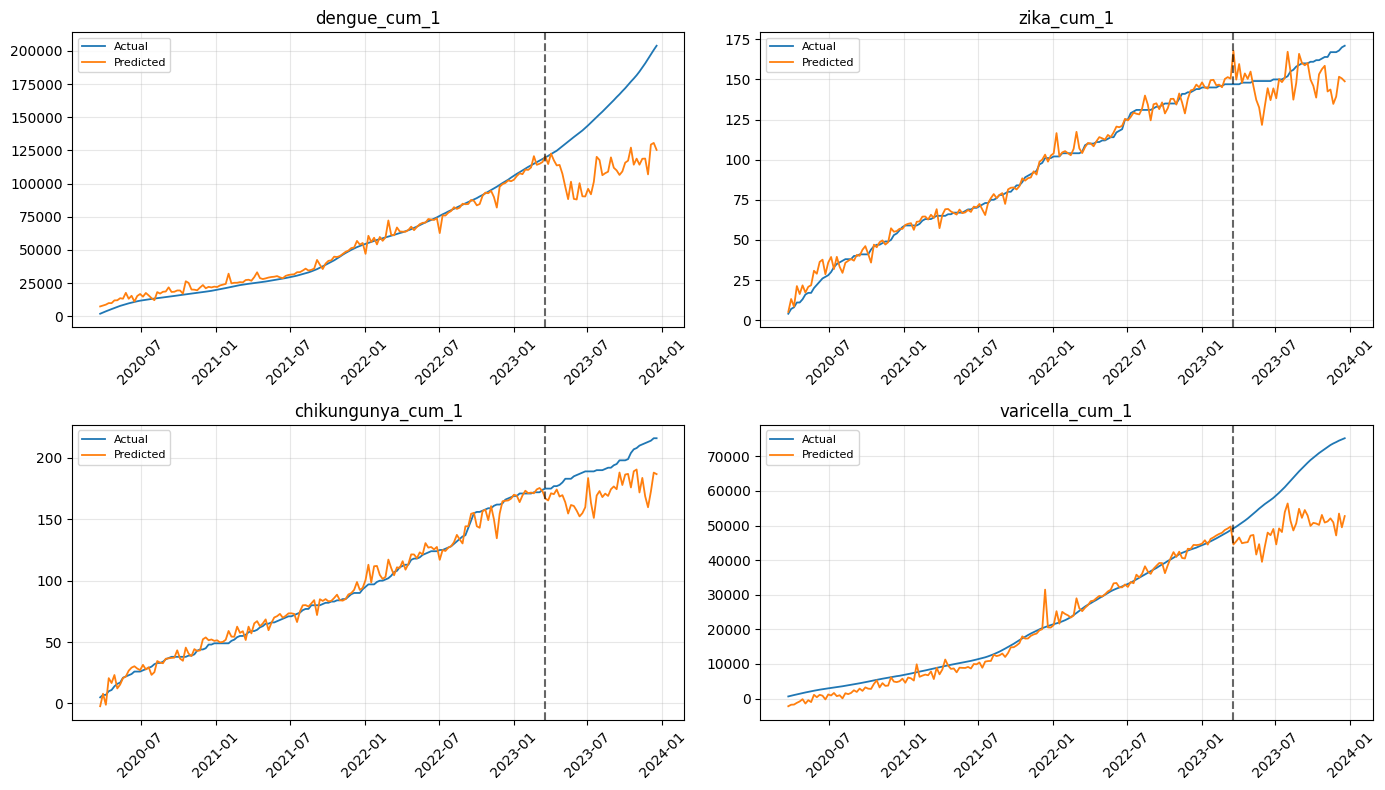

In [ ]:
# -----------------------------------------------
# 2.  Plot 2 × 2 grid
# -----------------------------------------------
fig_rows = 2
fig_cols = math.ceil(len(targets) / 2)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(14, 8))
axes = axes.flatten()

for i, tgt in enumerate(targets):
    if tgt not in pred_dict:
        continue
    ax = axes[i]

    df_act = df_epidemics[[date_col, tgt]].dropna().sort_values(date_col)
    dates  = df_act[date_col]
    actual = df_act[tgt].values
    preds  = pred_df[tgt].loc[dates].values

    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.set_title(tgt)
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide any unused subplot slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

If only use date and self lagged variable, the model is way better, if use all predictors, there is too much variance

In [ ]:
from google.colab import files
# save and download pred_df as csv
pred_df.to_csv('DNN_epidemics.csv')
files.download('DNN_epidemics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Feature Engineering

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
# -------------------------------------------------
# 0.  Configuration
# -------------------------------------------------
targets = ['dengue_cum_1', 'zika_cum_1',
           'chikungunya_cum_1', 'varicella_cum_1']
date_col = "date"

# keep this up‑to‑date with epidemic roots in your dataframe
base_names = ["dengue", "zika", "chikungunya", "varicella"]

# -----------------------------------------------
# 1.  Feature‑ranking helper
# -----------------------------------------------
def best_features_for_target(df_raw: pd.DataFrame,
                             target: str,
                             k: int = 5) -> list[str]:
    """Return top‑k predictive features for *target*."""

    df = df_raw.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["date_num"] = df[date_col].view("int64") // 10**9

    # ----- build candidate list exactly like in NN loop -----
    base     = target.split("_")[0]
    own_base = target.replace("_1", "")     # e.g. dengue_cum

    exclude  = {date_col, target}
    for epi in base_names:
        cols_with_epi = [c for c in df.columns if c.startswith(epi)]
        if epi == base:
            exclude.update([c for c in cols_with_epi if c != own_base])
        else:
            exclude.update(cols_with_epi)

    features = [c for c in df.columns if c not in exclude]

    # ----- drop rows with NaN in target or any candidate -----
    df = df.dropna(subset=[target] + features)
    if len(df) < 10:
        return []                          # not enough data

    X = df[features].values.astype("float64")
    y = df[target].values.astype("float64")

    # ----- basic preprocessing: median impute + scale ----------
    X = SimpleImputer(strategy="median").fit_transform(X)
    X = StandardScaler().fit_transform(X)

    # ----- mutual information scores ---------------------------
    mi = mutual_info_regression(X, y, random_state=42)
    top_idx = np.argsort(mi)[::-1][:k]       # indices of top k
    return [features[i] for i in top_idx]

# -----------------------------------------------
# 2.  Run for every target
# -----------------------------------------------
top_feats = {tgt: best_features_for_target(df_epidemics, tgt, k=5)
             for tgt in targets}

print("Top‑5 features per target")
for tgt, feats in top_feats.items():
    print(f"{tgt:20s} → {feats}")


<ipython-input-54-e878e4a1403f>:24: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
<ipython-input-54-e878e4a1403f>:24: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
<ipython-input-54-e878e4a1403f>:24: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9


Top‑5 features per target
dengue_cum_1         → ['dengue_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital']
zika_cum_1           → ['zika_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital']
chikungunya_cum_1    → ['chikungunya_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital']
varicella_cum_1      → ['varicella_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital']


<ipython-input-54-e878e4a1403f>:24: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9


In [ ]:
# --------------------------------------------------
# 0.  Assumes you already executed the block that
#     defines `top_feats`  (dict: target -> list[str])
# --------------------------------------------------
targets   = ['dengue_cum_1', 'zika_cum_1',
             'chikungunya_cum_1', 'varicella_cum_1']
date_col  = "date"

metrics   = {}          # {target: {"rmse", "r2"}}
pred_dict = {}          # {target: pd.DataFrame(date, pred)}

for tgt in targets:
    if tgt not in top_feats or len(top_feats[tgt]) == 0:
        print(f"{tgt}: skipped (no feature list available)")
        continue

    # ------------- data prep ----------------------
    df = df_epidemics.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values(date_col, inplace=True)
    df["date_num"] = df[date_col].view("int64") // 10**9

    predictors = top_feats[tgt] + ["date_num"]   # <= NEW
    print(f"{tgt}: predictors -> {predictors}")

    # drop any row with NaN in target or predictor(s)
    df_clean = df.dropna(subset=[tgt] + predictors).reset_index(drop=True)
    if len(df_clean) < 10:
        print(f"{tgt}: skipped (too few complete rows)")
        continue

    # ------------- split indices ------------------
    split_pt     = int(0.80 * len(df_clean))
    idx_trainval = np.arange(split_pt)
    idx_test     = np.arange(split_pt, len(df_clean))

    train_idx, val_idx = train_test_split(
        idx_trainval, test_size=0.20, shuffle=True, random_state=42)
    train_idx.sort(); val_idx.sort()

    X_tr   = df_clean.loc[train_idx, predictors].values.astype("float32")
    X_val  = df_clean.loc[val_idx,  predictors].values.astype("float32")
    X_test = df_clean.loc[idx_test, predictors].values.astype("float32")

    y_tr   = df_clean.loc[train_idx, tgt].values.astype("float32").reshape(-1, 1)
    y_val  = df_clean.loc[val_idx,  tgt].values.astype("float32").reshape(-1, 1)
    y_test = df_clean.loc[idx_test, tgt].values.astype("float32").reshape(-1, 1)

    # ------------- scaling ------------------------
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc = map(y_scaler.transform, (y_tr, y_val))

    # ------------- model --------------------------
    model = build_ffn(len(predictors))
    es    = EarlyStopping(monitor="val_loss",
                          patience=10, restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000,
        batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False,
        callbacks=[es],
        verbose=0
    )

    # ------------- metrics ------------------------
    y_pred_test = y_scaler.inverse_transform(
        model.predict(X_test_sc, verbose=0)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[tgt] = {"rmse": rmse, "r2": r2}

    # ------------- full‑series preds --------------
    X_full_sc = X_scaler.transform(
        df_clean[predictors].values.astype("float32"))
    y_pred_full = y_scaler.inverse_transform(
        model.predict(X_full_sc, verbose=0)).flatten()

    pred_dict[tgt] = pd.DataFrame({
        date_col: df_clean[date_col].values,
        "pred":   y_pred_full
    })

    K.clear_session()

# --------------------------------------------------
# 1.  Concatenate predictions (identical date index)
# --------------------------------------------------
pred_df = (pd.concat([df.set_index(date_col)["pred"]
                      .rename(tgt) for tgt, df in pred_dict.items()],
                     axis=1)
           .sort_index())

print(pred_df.head())
print("\nTest metrics\n-------------")
print(pd.DataFrame(metrics).T)


<ipython-input-58-729efea45150>:21: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dengue_cum_1: predictors -> ['dengue_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital', 'date_num']


<ipython-input-58-729efea45150>:21: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


zika_cum_1: predictors -> ['zika_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital', 'date_num']


<ipython-input-58-729efea45150>:21: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


chikungunya_cum_1: predictors -> ['chikungunya_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital', 'date_num']


<ipython-input-58-729efea45150>:21: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


varicella_cum_1: predictors -> ['varicella_cum', 'date_num', 'mob_index', 'google_physician', 'google_hospital', 'date_num']
            dengue_cum_1  zika_cum_1  chikungunya_cum_1  varicella_cum_1
date                                                                    
2020-03-23  11257.089844   22.060270          12.448663      1503.948608
2020-03-30   4459.765625   20.543734          12.222817      1108.628296
2020-04-06      8.679813   19.464609          10.204484       182.139999
2020-04-13   5596.453125   20.422281          13.160798      1268.427124
2020-04-20   5544.074219   23.371614          14.788560      1160.108765

Test metrics
-------------
                           rmse        r2
dengue_cum_1       26183.315604 -0.133103
zika_cum_1             5.356815  0.504203
chikungunya_cum_1      4.225851  0.880532
varicella_cum_1     8194.168658  0.037701


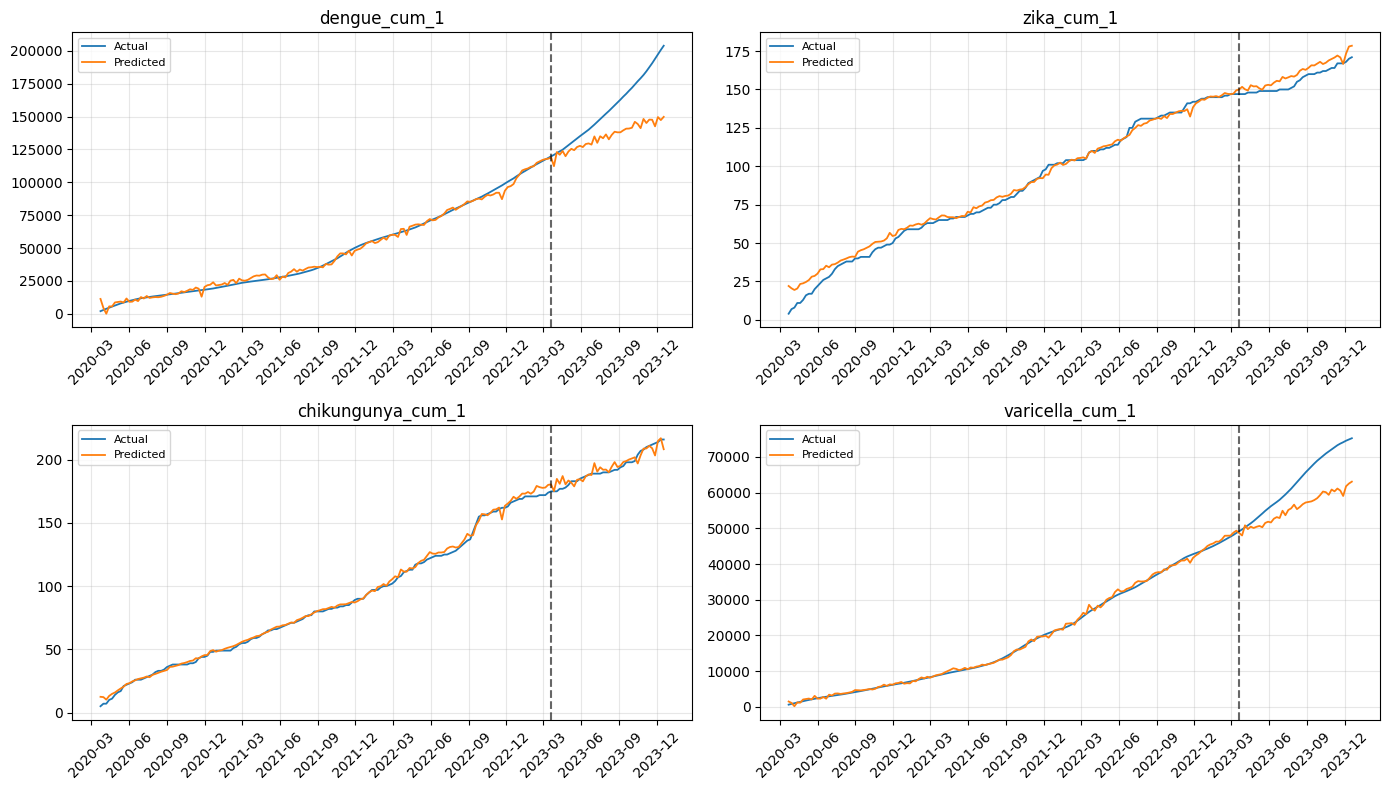

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# --------------------------------------------------
# 2 × 2 grid: actual vs. predicted for each target
# --------------------------------------------------
fig_rows = 2
fig_cols = math.ceil(len(targets) / 2)
fig, axes = plt.subplots(fig_rows, fig_cols,
                         figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, tgt in enumerate(targets):
    ax = axes[i]

    # --------------- actual & predicted ---------------
    df_act = df_epidemics[[date_col, tgt]].dropna().sort_values(date_col)
    dates  = pd.to_datetime(df_act[date_col])
    actual = df_act[tgt].values
    preds  = pred_df[tgt].loc[dates].values

    ax.plot(dates, actual, label="Actual",    linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    # --------------- train‑test split marker ----------
    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    # --------------- tidy x‑axis ----------------------
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # every 3 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y‑%m'))
    ax.tick_params(axis="x", rotation=45)

    ax.set_title(tgt)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide unused subplot slots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


## Best features selection

<ipython-input-22-d83a66c20b22>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_fs["date_num"] = df_fs[date_col].view("int64") // 10**9


⚠️  dengue_cum_1: selector empty → using top‑1 feature dengue_cum


<ipython-input-22-d83a66c20b22>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_fs["date_num"] = df_fs[date_col].view("int64") // 10**9


⚠️  zika_cum_1: selector empty → using top‑1 feature zika_cum


<ipython-input-22-d83a66c20b22>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_fs["date_num"] = df_fs[date_col].view("int64") // 10**9


⚠️  chikungunya_cum_1: selector empty → using top‑1 feature chikungunya_cum


<ipython-input-22-d83a66c20b22>:49: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df_fs["date_num"] = df_fs[date_col].view("int64") // 10**9


⚠️  varicella_cum_1: selector empty → using top‑1 feature varicella_cum


<ipython-input-22-d83a66c20b22>:116: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
<ipython-input-22-d83a66c20b22>:116: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df["date_num"] = df[date_col].view("int64") // 10**9
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` ob


Test metrics
-------------
                           rmse        r2
dengue_cum_1       15632.985639  0.596072
zika_cum_1             6.606682  0.245851
chikungunya_cum_1      1.745124  0.979626
varicella_cum_1     3046.337637  0.866999


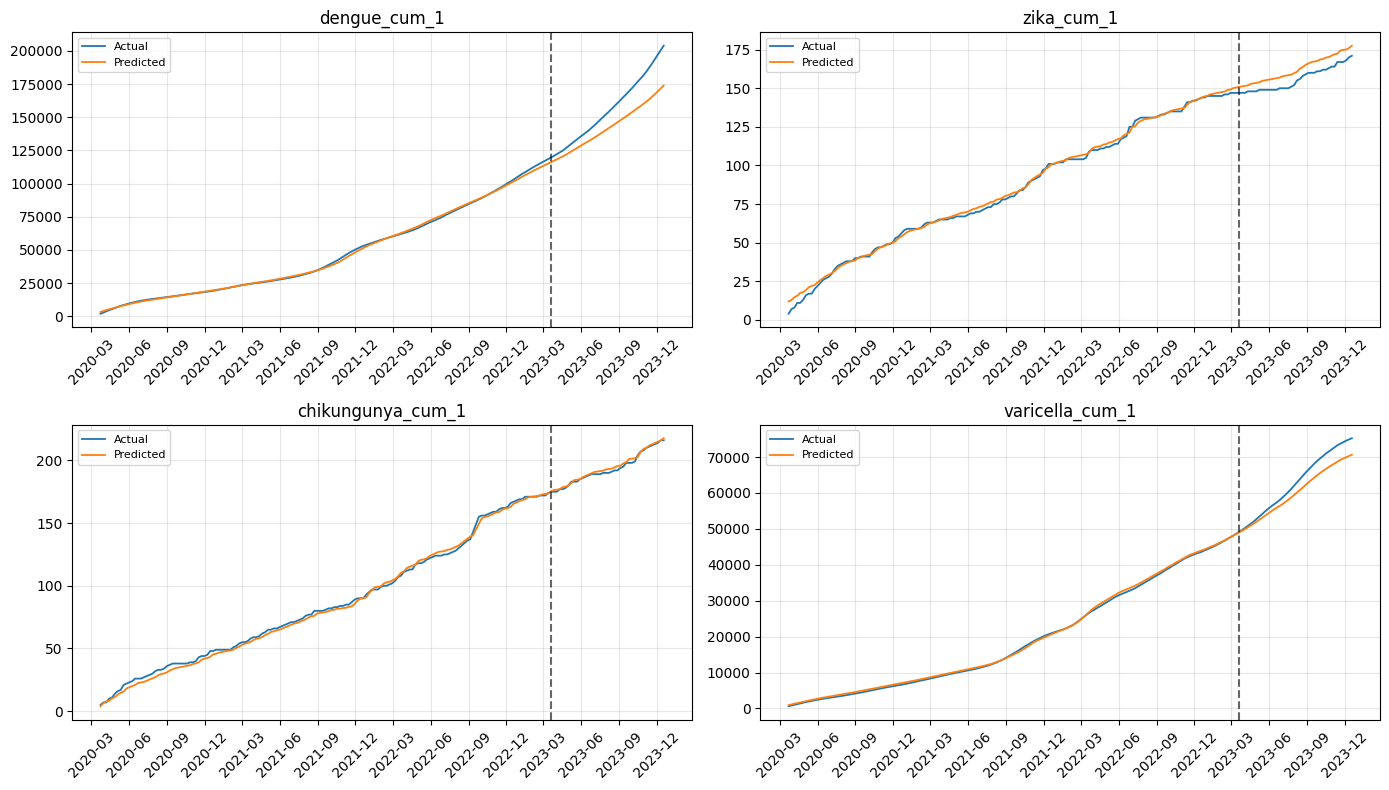

In [22]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection   import cross_val_score, KFold, train_test_split
from sklearn.metrics           import mean_squared_error, make_scorer, r2_score
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.ensemble          import GradientBoostingRegressor

from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras          import backend as K

# --------------------------------------------------
# 0.  Configuration
# --------------------------------------------------
date_col  = "date"
targets   = ['dengue_cum_1', 'zika_cum_1',
             'chikungunya_cum_1', 'varicella_cum_1']
base_names = ["dengue", "zika", "chikungunya", "varicella"]

def build_ffn(d):
    m = Sequential([
        Dense(128, activation="relu", input_shape=(d,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

# --------------------------------------------------
# 1.  Feature‑selection stage  (with fallbacks)
# --------------------------------------------------
cv           = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer  = make_scorer(mean_squared_error, greater_is_better=False, squared=False)
best_feats   = {}        # dict[target] = list[str]

for tgt in targets:
    df_fs = df_epidemics.copy()
    df_fs[date_col] = pd.to_datetime(df_fs[date_col])
    df_fs["date_num"] = df_fs[date_col].view("int64") // 10**9

    base     = tgt.split("_")[0]
    own_base = tgt.replace("_1", "")

    # --- build candidate set -----------------------------------
    exclude = {date_col, tgt}
    for epi in base_names:
        cols = [c for c in df_fs.columns if c.startswith(epi)]
        if epi == base:
            exclude.update([c for c in cols if c != own_base])
        else:
            exclude.update(cols)
    candidates = [c for c in df_fs.columns if c not in exclude]

    df_fs = df_fs.dropna(subset=[tgt] + candidates)
    if len(df_fs) < 10:
        best_feats[tgt] = []                  # fallback → date_num only
        print(f"{tgt}: not enough data; using time only")
        continue

    X = df_fs[candidates].values
    y = df_fs[tgt].values

    # --- MI ranking -------------------------------------------
    mi = mutual_info_regression(X, y, random_state=42)
    ranked = [candidates[i] for i in np.argsort(mi)[::-1]]

    pipe = Pipeline([
        ("imp",  SimpleImputer(strategy="median")),
        ("sc",   StandardScaler()),
        ("gbr",  GradientBoostingRegressor(random_state=42))
    ])

    best_score, best_subset = -np.inf, []
    for k in range(1, len(ranked) + 1):
        subset = ranked[:k]
        score  = cross_val_score(pipe,
                                 df_fs[subset].values, y,
                                 cv=cv, scoring=rmse_scorer,
                                 n_jobs=-1).mean()
        if score > best_score:
            best_score, best_subset = score, subset

    # ---------- Fallbacks -------------------------------------
    if not best_subset:                   # selector returned 0
        if ranked:                        # Fallback A → top‑1 feature
            best_subset = [ranked[0]]
            print(f"⚠️  {tgt}: selector empty → using top‑1 feature {best_subset[0]}")
        else:                             # Fallback B → time only
            best_subset = []
            print(f"⚠️  {tgt}: no candidates → using time only")
    else:
        print(f"{tgt}: {len(best_subset)} feature(s), CV‑RMSE = {-best_score:.2f}")

    best_feats[tgt] = best_subset

# --------------------------------------------------
# 2.  Neural‑network training & prediction
# --------------------------------------------------
metrics   = {}          # {target: {"rmse", "r2"}}
pred_dict = {}          # {target: pd.DataFrame([date, pred])}

for tgt in targets:
    df = df_epidemics.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values(date_col, inplace=True)
    df["date_num"] = df[date_col].view("int64") // 10**9

    predictors = best_feats.get(tgt, []) + ["date_num"]   # time always present
    df_clean = df.dropna(subset=[tgt] + predictors).reset_index(drop=True)
    if len(df_clean) < 10:
        print(f"{tgt}: skipped (too few rows after cleaning)")
        continue

    # chronological split
    split_pt     = int(0.80 * len(df_clean))
    idx_trainval = np.arange(split_pt)
    idx_test     = np.arange(split_pt, len(df_clean))

    tr_idx, val_idx = train_test_split(idx_trainval, test_size=0.20,
                                       shuffle=True, random_state=42)
    tr_idx.sort(); val_idx.sort()

    X_tr   = df_clean.loc[tr_idx,  predictors].astype("float32").values
    X_val  = df_clean.loc[val_idx, predictors].astype("float32").values
    X_test = df_clean.loc[idx_test, predictors].astype("float32").values

    y_tr   = df_clean.loc[tr_idx,  tgt].astype("float32").values.reshape(-1, 1)
    y_val  = df_clean.loc[val_idx, tgt].astype("float32").values.reshape(-1, 1)
    y_test = df_clean.loc[idx_test, tgt].astype("float32").values.reshape(-1, 1)

    # scaling
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc = map(y_scaler.transform, (y_tr, y_val))

    # NN
    model = build_ffn(len(predictors))
    es = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000, batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False, callbacks=[es], verbose=0
    )

    # metrics
    y_pred_test = y_scaler.inverse_transform(
        model.predict(X_test_sc, verbose=0)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[tgt] = {"rmse": rmse, "r2": r2}

    # full‑series prediction
    X_full_sc = X_scaler.transform(df_clean[predictors].astype("float32").values)
    y_pred_full = y_scaler.inverse_transform(
        model.predict(X_full_sc, verbose=0)).flatten()

    pred_dict[tgt] = pd.DataFrame({date_col: df_clean[date_col], "pred": y_pred_full})
    K.clear_session()

# concat predictions
pred_df = (pd.concat([df.set_index(date_col)["pred"].rename(tgt)
                      for tgt, df in pred_dict.items()], axis=1)
           .sort_index())

print("\nTest metrics\n-------------")
print(pd.DataFrame(metrics).T)

# --------------------------------------------------
# 3.  Plot actual vs. predicted (2 × 2 grid)
# --------------------------------------------------
fig_rows, fig_cols = 2, math.ceil(len(targets) / 2)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(14, 8))
axes = axes.flatten()

for i, tgt in enumerate(targets):
    ax = axes[i]

    df_act = df_epidemics[[date_col, tgt]].dropna().sort_values(date_col)
    dates  = pd.to_datetime(df_act[date_col])
    actual = df_act[tgt].values
    preds  = pred_df[tgt].loc[dates].values

    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y‑%m'))
    ax.tick_params(axis="x", rotation=45)

    ax.set_title(tgt)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

In [23]:
pred_df.to_csv("DNN_epidemics_best_features.csv")
files.download('DNN_epidemics_best_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_feats

{'dengue_cum_1': ['dengue_cum'],
 'zika_cum_1': ['zika_cum'],
 'chikungunya_cum_1': ['chikungunya_cum'],
 'varicella_cum_1': ['varicella_cum']}